# Week 1: Projectile Motion using Euler's Method

## This notebook should be used in conjunction with the Canvas Quizz: Computational Physics Lab 1

In [33]:
import numpy as np
import matplotlib.pyplot as plt

# Part I: Euler Method

In [34]:
# ---------- Simple projectile motion using Euler's method ---------- #

 ## Function inputs: 
    # speed_m (initial speed)
    # angle (initial angle)
    # tau (time step)
    # dimTau (True/False: whether the tau provided is dimensional or non-dimensional)       
 
def proj_euler(speed_m, angle, tau, dimTau=False):

    # Dimensionalisation parameters
    G = 9.8  # Acceleration due to gravity (m/s^2)
    Ls = 1  # Choice for scaling length (m)
    Ts = np.sqrt(Ls / G)  # Scale for time (s)

    if dimTau == True:
        tau = tau/Ts # makes tau non dimensional!

    # Convert angle to radians
    angle = np.radians(angle)

    # Non-dimensionalise initial speed
    speed = speed_m / (Ls / Ts)

    # Row vectors for non-dimensional position and velocity
    pos = np.array([0, 0])
    vel = speed * np.array([np.cos(angle), np.sin(angle)])

    # Store Initial Condition (for plotting):
    x, y = [pos[0]], [pos[1]]

    # ---- Euler's method ---- #
    
    while pos[1] >= 0:
        
        # Compute one step of Euler's method:
        # First update position using current velocity
        pos = pos + tau * vel
        # Then update velocity with gravity
        vel = vel + tau * np.array([0, -1])

        # Store position for plotting
        x.append(pos[0])
        y.append(pos[1])

    # ---- Estimate Range ---- #

    # Linear interpolation to estimate the range of the projectile
    coOrdsOver = np.array([x[-2], y[-2]])  # Last point projectile above axis
    coOrdsUnder = np.array([x[-1], y[-1]])  # Projectile under ground
    range = coOrdsUnder[0] - coOrdsUnder[1] * (coOrdsUnder[0] - coOrdsOver[0]) / (coOrdsUnder[1] - coOrdsOver[1])
    range_m = Ls * range  # Convert back to m

    # Analytic expression for range
    an_range_m = (speed_m**2 * np.sin(2 * angle)) / G

    return range_m, an_range_m


## _Q1:_
### Determine the range for the Euler's method solution with the non-dimensional time step $\tau=0.1$.

Run the code proj_euler with initial conditions $v_1 = 50$ m/s and $\theta_1 = 40$ deg. Determine the range for the Euler’s method solution with the non-dimensional time step $\tau = 0.1$.

In [35]:
## Solution: the range is computed as an output of the Lab1 function. 
# You just need to use the input values as provided in the task
range_m, an_range_m = proj_euler(50, 40, 0.1, False)
print(range_m)

252.4486763106218


## _Q2:_
### What is the percentage error in Euler's method?
What is the percentage error in the Euler’s method result for the range R compared with the (exact) analytic range given by $R = v_1^2\sin\left(2\theta_1\right)/g$ where $v_1$ is the initial speed and $\theta_1$ is the initial angle to the horizontal?

In [36]:
## Solution: calculate the % error using the numerical and analytical range
Error_p = 100*(range_m-an_range_m)/an_range_m
print(Error_p) # in %

0.48649679196526174


## _Q3:_
### What is the dominant source of error in our estimate of the range using Euler's method as above?

Solution:
The error is a global truncation error, a combination of the errors at each time step caused by the
use of a finite time step, $\tau$. The truncation error scales as $\tau^2$ at each time step.

## _Q4:_
### What dimensional time step (in seconds) does the non-dimensional time step $\tau=0.1$ correspond to?

In [37]:
## Solution: 

tau = 0.1 #non-dimensional time step

# Dimensionalisation parameters
G = 9.8  # Acceleration due to gravity (m/s^2)
Ls = 1  # Choice for scaling length (m)
Ts = np.sqrt(Ls / G)  # Scale for time (s)
# Dimensional time step
tau_d = tau*Ts

print(tau_d)

0.031943828249996996


## _Q5:_
### Produce a table with columns of the time step, the Euler's method estimate of the range, and the percentage error in the range by comparison with the analytic formula.

Modify the code so that it prompts the user for the value of the time step τ (in seconds) as well as the initial (dimensional) speed and angle, and run the code for the same initial conditions $v_1=50$ m/s and $\theta_1 = 40$ deg but for (dimensional) time steps $\tau = 0.001$ s, $\tau = 0.01$ s, $\tau = 0.1$ s and $\tau = 1$ s.

Note: The quantities used within the code are non-dimensional, so you will need to convert a dimensional value for $\tau$ (supplied by the user) into a non-dimensional value.


In [38]:
# Solution: Call the function Lab1 but use 'True' for dimTau. Repeat for each dimensional tau
tau=0.001
range_m, an_range_m = proj_euler(50, 40, tau, True)
Error_p = 100*(range_m-an_range_m)/an_range_m
print(tau, range_m, Error_p) 



0.001 251.2647695122562 0.015245968096533105


## _Q6:_
### When the value of $\tau$ is increased by a factor of ten, by what factor does the error change?



Solution: From the table, we can see that when the value of $\tau$ is increased by a factor of ten, the error also increases by a factor of ten: the global error scales linearly with$\tau$, i.e., it is a constant times $\tau$.

## _Q7:_
### Briefly outline the relevant argument for how the global error is predicted to scale with $\tau$; complete your answer with a brief statement about why the predicted scaling with $\tau$ is consistent with your results.



Solution:
This is consistent with the naive estimate from the lecture. The error in position in a single step
(the local truncation error) is $\approx 1/2 \tau^2g$, and the global error (the error over all of the steps) is expected to be $\approx$ number of steps × local error = $\frac{T}{\tau}\frac{1}{2}\tau^2g$ = $1/2T\tau g$, where $T$ is the time of flight. Hence, it is expected to scale with $\tau$.

# Part II: Midpoint Method

The code in Lab1 uses Euler's method to integrate the dynamics equations:

$r_{n+1}=r_n+\tau v_n$\
$v_{n+1}=v_n+\tau a_n$.

Consider instead the "Midpoint method", which has the updates:

$v_{n+1}=v_n+\tau a_n$\
$r_{n+1}=r_n+\frac{1}{2}\tau(v_n+v_{n+1})$.

Note that with the midpoint method, the velocity update must be done before the position update.

## _Q8:_
### What is the local truncation error in position for the midpoint method?

Hint: Substitute the expression for $v_{n+1}$ for the midpoint method into the expression for $r_{n+1}$, and show that the result matches the Taylor series expansion for position to a certain order.

Solution:

The midpoint method is \
$v_{n+1}=v_n+\tau a_n$ (1)\
$r_{n+1}=r_n+\frac{1}{2}\tau(v_n+v_{n+1})$ (2).

Substituting Eq. (1) into Eq. (2) gives:
$$
r_{n+1} = r_n + \tau v_n + \frac{1}{2}\tau^2 a_n
= r(t_n) + \tau \left.\frac{dr}{dt}\right|_{t_n}
+ \frac{1}{2}\tau^2 \left.\frac{d^2 r}{dt^2}\right|_{t_n}
+ $$

This represents the first three terms of the Taylor expansion for $r$ at $t_n$ with step $\tau$. The truncation error is the omission of the subsequent terms. Hence, the local truncation error is $O(\tau^3)$, corresponding to the leading missing term.

## _Q9:_

### Modify your code from Question 1 to use the midpoint method, rather than Euler's method, for the simple projectile motion problem.

Note: The midpoint method velocity update must be performed before the position update.

Your code should calculate the analytic range using $R=v_1^2\sin (2\theta_1 )/g$ in the same way as in the Euler method above. Have your code calculate the (magnitude of the) percentage error in the range estimate.

Apply your code to the case $v_1 = 50$ m/s and $\theta_1 = 40$ deg, with $\tau = 0.5$ s.

What is the percentage error in the range, compared with the exact (analytic) value?

In [39]:
# ---------- Simple projectile motion using Midpoint method ---------- #

 ## Function inputs: 
    # speed_m (initial speed)
    # angle (initial angle)
    # tau (time step)
    # dimTau (True/False: whether the tau provided is dimensional or non-dimensional)       
 
def proj_midpoint(speed_m, angle, tau, dimTau=False):

    # Dimensionalisation parameters
    G = 9.8  # Acceleration due to gravity (m/s^2)
    Ls = 1  # Choice for scaling length (m)
    Ts = np.sqrt(Ls / G)  # Scale for time (s)

    if dimTau == True:
        tau = tau/Ts # makes tau non dimensional!

    # Convert angle to radians
    angle = np.radians(angle)

    # Non-dimensionalise initial speed
    speed = speed_m / (Ls / Ts)

    # Row vectors for non-dimensional position and velocity
    pos = np.array([0, 0])
    vel = speed * np.array([np.cos(angle), np.sin(angle)])

    # Store Initial Condition (for plotting):
    x, y = [pos[0]], [pos[1]]

    # ---- Midpoint method ---- #
    
    while pos[1] >= 0:
        
        # Compute one step of Midpoint method:
        # First update velocity using current velocity and gravity
        velp=vel
        vel = velp + tau * np.array([0, -1])
        
        # Then update position with velocity
        pos = pos + 0.5*tau*(vel+velp) 

        # Store position for plotting
        x.append(pos[0])
        y.append(pos[1])

    # ---- Estimate Range ---- #

    # Linear interpolation to estimate the range of the projectile
    coOrdsOver = np.array([x[-2], y[-2]])  # Last point projectile above axis
    coOrdsUnder = np.array([x[-1], y[-1]])  # Projectile under ground
    range = coOrdsUnder[0] - coOrdsUnder[1] * (coOrdsUnder[0] - coOrdsOver[0]) / (coOrdsUnder[1] - coOrdsOver[1])
    range_m = Ls * range  # Convert back to m

    # Analytic expression for range
    an_range_m = (speed_m**2 * np.sin(2 * angle)) / G

    return range_m, an_range_m


In [40]:
range_m_mid, an_range_m_mid = proj_midpoint(50, 40, 0.5, True)
Error_p_mid = 100*(range_m_mid - an_range_m_mid)/an_range_m_mid
print(Error_p_mid)

-0.05719992900522245


## _Q10:_
### What is the scaling of the absolute percentage error $E$ with $\tau$?
Run your midpoint method code for the values of the non-dimensional time step $\tau = 0.001$, $\tau = 0.01$, $\tau = 0.1$, and $\tau=1$.

Plot the (magnitude of the) percentage error versus $\tau$.

What is the scaling of the absolute percentage error $E$ with $\tau$?


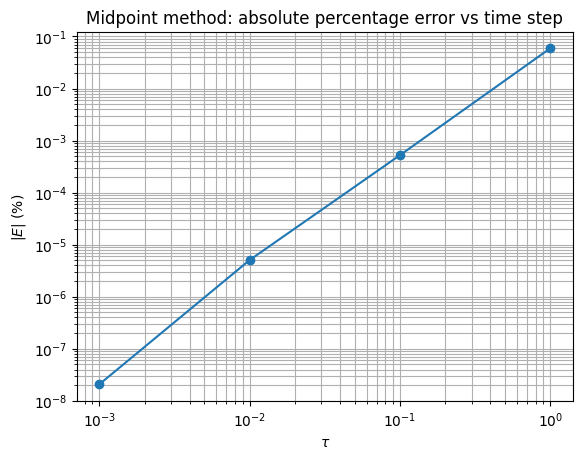

taus = [0.001 0.01  0.1   1.   ]
|E| (%) = [2.07965148e-08 5.06979190e-06 5.24337473e-04 5.92278970e-02]
Best-fit scaling: |E| ≈ 0.0685 * tau^2.138
Estimated order p ≈ 2.138 (so error scales like tau^2 if close to an integer)


In [41]:
#Solution: run a loop over taus and plot the outcome

import numpy as np
import matplotlib.pyplot as plt

# --- Q10: scaling of absolute percentage error with tau (midpoint method) ---

taus = np.array([0.001, 0.01, 0.1, 1.0], dtype=float)

errors_pct = []
for tau in taus:
    # Expecting your midpoint function to return (range_m, an_range_m)
    # If your function name/args differ, change the next line accordingly.
    range_m, an_range_m = proj_midpoint(50, 40, tau, False)

    # Percentage error (absolute magnitude, as requested)
    E = 100.0 * (range_m - an_range_m) / an_range_m
    errors_pct.append(abs(E))

errors_pct = np.array(errors_pct)

# Plot |percentage error| vs tau
plt.figure()
plt.loglog(taus, errors_pct, marker='o')
plt.xlabel(r'$\tau$')
plt.ylabel(r'$|E|$ (%)')
plt.title('Midpoint method: absolute percentage error vs time step')
plt.grid(True, which='both')
plt.show()

# Fit scaling: |E| ~ C * tau^p  => log|E| = log C + p log tau
p, logC = np.polyfit(np.log(taus), np.log(errors_pct), 1)
C = np.exp(logC)

print(f"taus = {taus}")
print(f"|E| (%) = {errors_pct}")
print(f"Best-fit scaling: |E| ≈ {C:.3g} * tau^{p:.3f}")
print(f"Estimated order p ≈ {p:.3f} (so error scales like tau^{p:.0f} if close to an integer)")


## _Q11:_
### Which of the following factors is the dominant source of error you (should have) observed above for the range, $R$?



Solution: The midpoint method is exact for simple projectile motion, but the range is determined from
the last two positions by linear interpolation. This incurs a truncation error $O(\tau^2)$, as shown in Q10.